# Using the pulsar population data release

This notebook uses only NumPy and Matplotlib.

In [1]:
from pathlib import Path
import gzip
import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
if not (HERE / 'hyperposterior_samples').exists():
    HERE = Path('data_release')
print('Reading data from:', HERE.resolve())

Reading data from: /Users/lisadrummond/Dropbox/2024/Research/NeutronStarsEM/data_release


## Hyperposterior samples

Here we compare one parameter with and without selection.

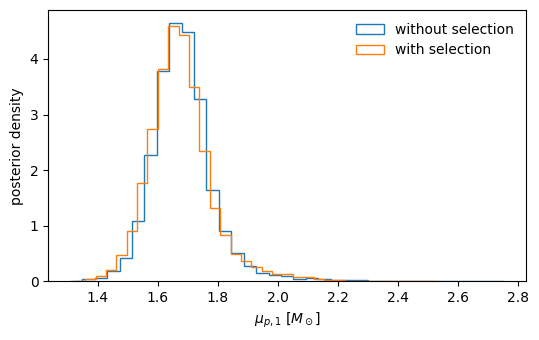

In [8]:
def load_named(path):
    return np.genfromtxt(path, names=True)

no = load_named(HERE / 'hyperposterior_samples' / 'without_selection.txt')
yes = load_named(HERE / 'hyperposterior_samples' / 'with_selection.txt')

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.hist(no['mu_p_2'], bins=35, density=True, histtype='step', label='without selection')
ax.hist(yes['mu_p_2'], bins=35, density=True, histtype='step', label='with selection')
ax.set(xlabel=r'$\mu_{p,1}\ [M_\odot]$', ylabel='posterior density')
ax.legend(frameon=False)
plt.tight_layout()

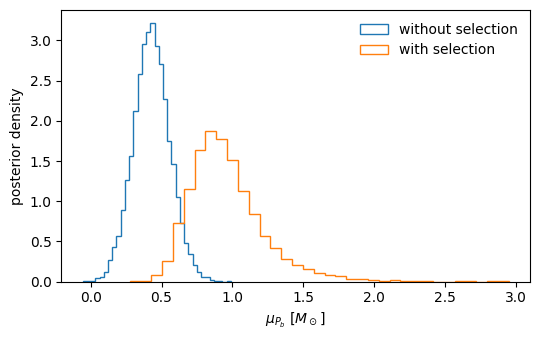

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.hist(no['mu_log10_pb'], bins=35, density=True, histtype='step', label='without selection')
ax.hist(yes['mu_log10_pb'], bins=35, density=True, histtype='step', label='with selection')
ax.set(xlabel=r'$\mu_{P_b}\ [M_\odot]$', ylabel='posterior density')
ax.legend(frameon=False)
plt.tight_layout()

## Selection function

The marginal tables make one-dimensional plots. The second plot loads the complete five-dimensional table, sums over eccentricity, orbital period, and spin period; plots the selected fraction against pulsar mass and companion mass.

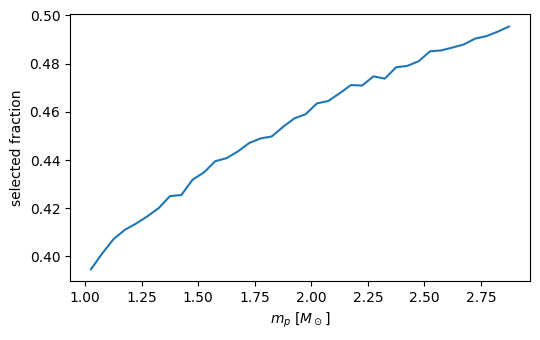

In [3]:
marginal = load_named(HERE / 'selection_function' / 'marginal_mp.txt')
x = 0.5 * (marginal['left_edge'] + marginal['right_edge'])
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(x, marginal['selected_fraction'])
ax.set(xlabel=r'$m_p\ [M_\odot]$', ylabel='selected fraction')
plt.tight_layout()

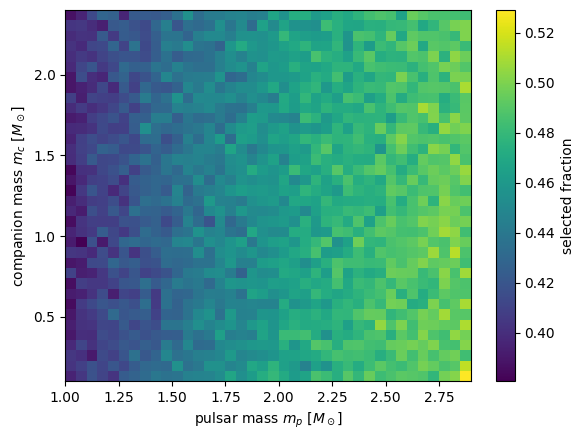

In [4]:
full_selection = np.loadtxt(HERE / 'selection_function' / 'selection_5d.txt.gz')
edge_table = np.genfromtxt(
    HERE / 'selection_function' / 'bin_edges.txt',
    names=True, dtype=None, encoding='utf-8',
)

def get_edges(parameter):
    return edge_table['edge_value'][edge_table['parameter'] == parameter]

mp_edges = get_edges('mp_msun')
mc_edges = get_edges('mc_msun')
selected_fraction = np.zeros((len(mp_edges) - 1, len(mc_edges) - 1))
np.add.at(
    selected_fraction,
    (full_selection[:, 0].astype(int), full_selection[:, 1].astype(int)),
    full_selection[:, 5],
)
# The injections are uniform, so divide by the expected number in each mass-bin pair.
selected_fraction /= 10_000_000 / selected_fraction.size

fig, ax = plt.subplots(figsize=(6, 4.5))
image = ax.pcolormesh(mp_edges, mc_edges, selected_fraction.T, shading='auto')
ax.set(xlabel=r'pulsar mass $m_p\ [M_\odot]$', ylabel=r'companion mass $m_c\ [M_\odot]$')
fig.colorbar(image, ax=ax, label='selected fraction')
fig.tight_layout()

## Individual reconstructed pulsar posteriors

There is one text file per pulsar system containing posterior samples. Each file contains pulsar mass, companion mass and orbital inclination. The three figures below show all 46 pulsar contours together.

46 pulsars; 16000 samples each


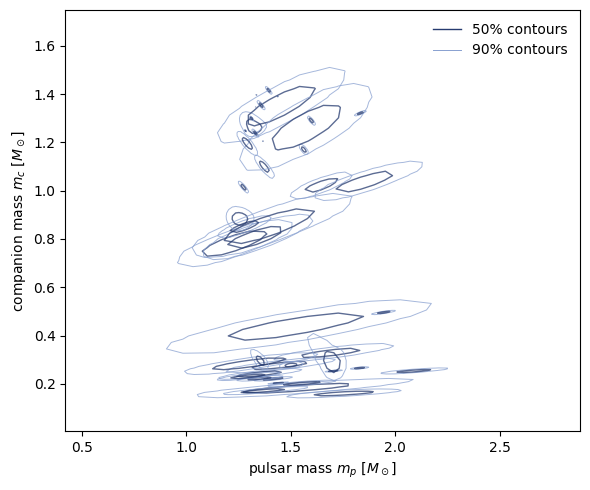

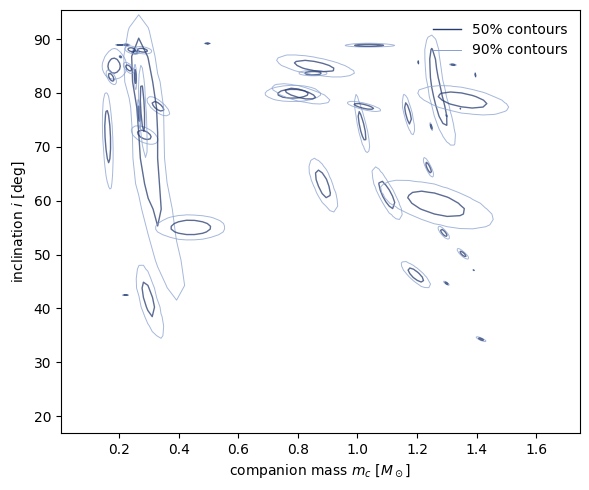

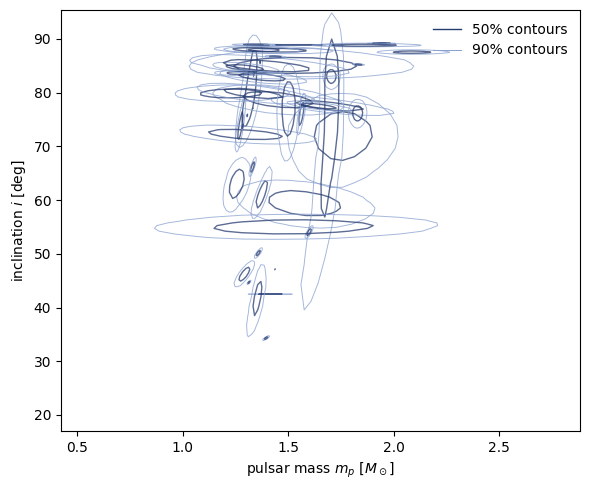

In [12]:
catalog = np.genfromtxt(HERE / 'individual_pulsar_posteriors' / 'catalog.txt', names=True, dtype=None, encoding='utf-8')
samples_by_system = {
    row['system']: load_named(HERE / 'individual_pulsar_posteriors' / row['filename'])
    for row in catalog
}

def contour_levels(density, probabilities=(0.90, 0.50)):
    ordered = np.sort(density.ravel())[::-1]
    cumulative = np.cumsum(ordered) / ordered.sum()
    levels = [ordered[min(np.searchsorted(cumulative, p), len(ordered)-1)] for p in probabilities]
    levels = np.unique(levels)
    if len(levels) < 2:
        levels = np.array([0.35, 0.70]) * density.max()
    return np.sort(levels)

def contour_density(density):
    kernel = np.array([1.0, 2.0, 1.0]) / 4.0
    density = np.apply_along_axis(lambda row: np.convolve(row, kernel, mode='same'), 0, density)
    return np.apply_along_axis(lambda row: np.convolve(row, kernel, mode='same'), 1, density)

def plot_all_contours(x_name, y_name, x_label, y_label):
    fig, ax = plt.subplots(figsize=(6, 5))
    all_x, all_y = [], []
    for row in catalog:
        samples = samples_by_system[row['system']]
        x, y = samples[x_name], samples[y_name]
        all_x.append(x)
        all_y.append(y)
        x_pad = max(0.20 * np.ptp(x), 1e-5)
        y_pad = max(0.20 * np.ptp(y), 1e-5)
        density, x_edges, y_edges = np.histogram2d(
            x, y, bins=20,
            range=[[x.min()-x_pad, x.max()+x_pad], [y.min()-y_pad, y.max()+y_pad]],
        )
        density = contour_density(density)
        x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
        y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
        ax.contour(x_centers, y_centers, density.T, levels=contour_levels(density),
                   colors=['#88a0d0', '#263b70'], linewidths=[0.7, 1.0], alpha=0.75)
    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)
    x_margin = 0.08 * np.ptp(all_x)
    y_margin = 0.08 * np.ptp(all_y)
    ax.set_xlim(all_x.min()-x_margin, all_x.max()+x_margin)
    ax.set_ylim(all_y.min()-y_margin, all_y.max()+y_margin)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.plot([], [], color='#263b70', lw=1.0, label='50% contours')
    ax.plot([], [], color='#88a0d0', lw=0.7, label='90% contours')
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig

plot_all_contours('mp_msun', 'mc_msun', r'pulsar mass $m_p\ [M_\odot]$', r'companion mass $m_c\ [M_\odot]$')
plot_all_contours('mc_msun', 'inclination_deg', r'companion mass $m_c\ [M_\odot]$', r'inclination $i\ [\mathrm{deg}]$')
plot_all_contours('mp_msun', 'inclination_deg', r'pulsar mass $m_p\ [M_\odot]$', r'inclination $i\ [\mathrm{deg}]$')
print(f'{len(catalog)} pulsars; {len(next(iter(samples_by_system.values())))} samples each')